<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION

Dataset Shape:
(75357, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.33984

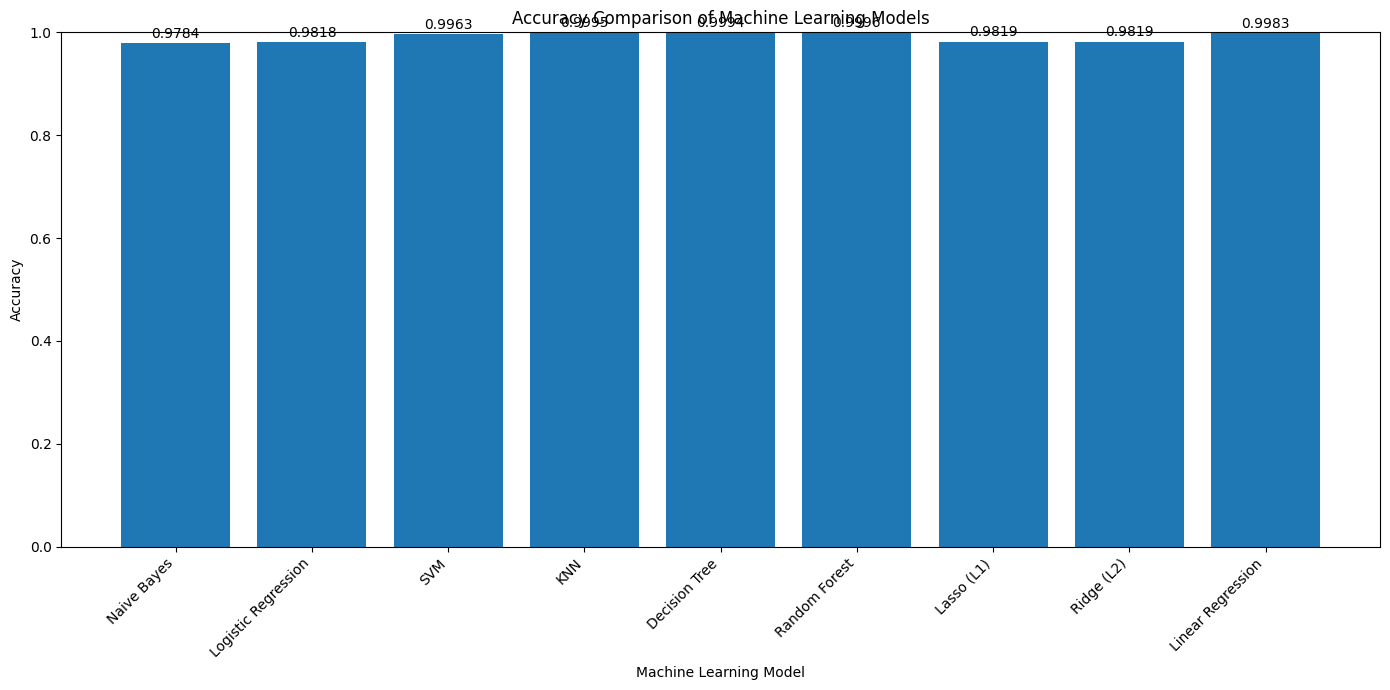

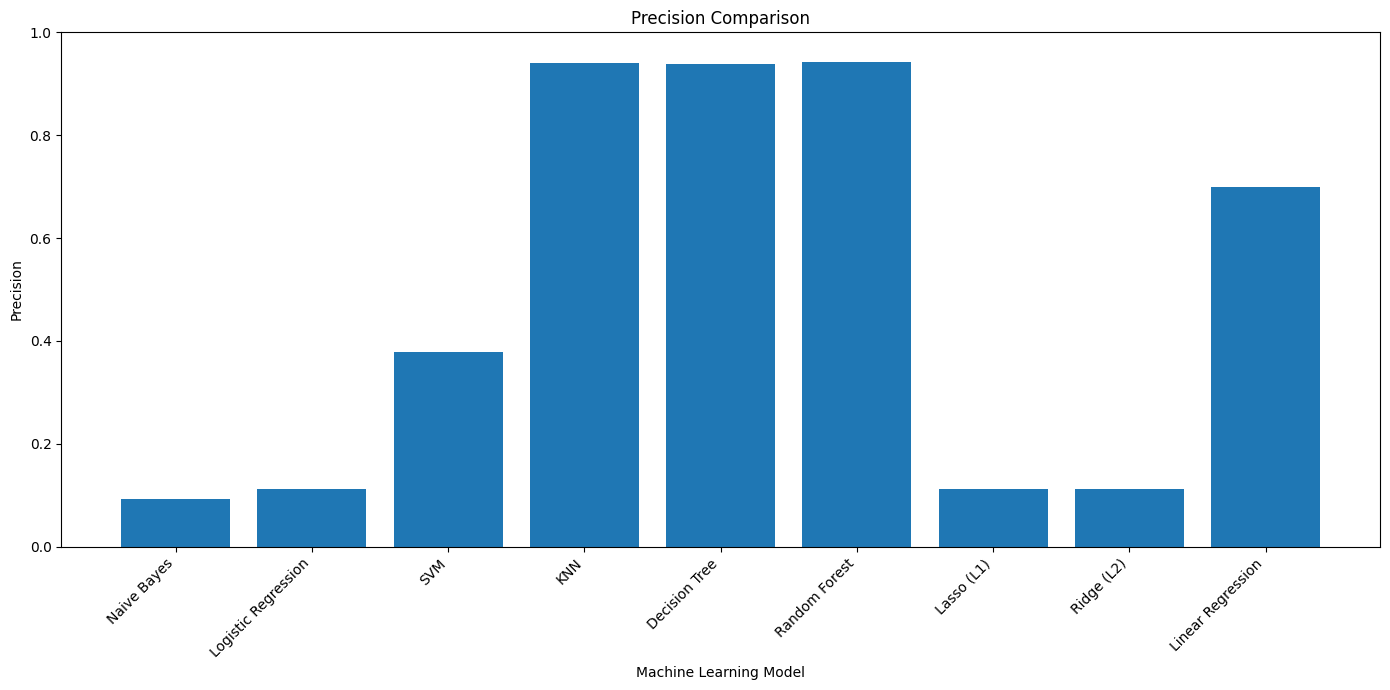

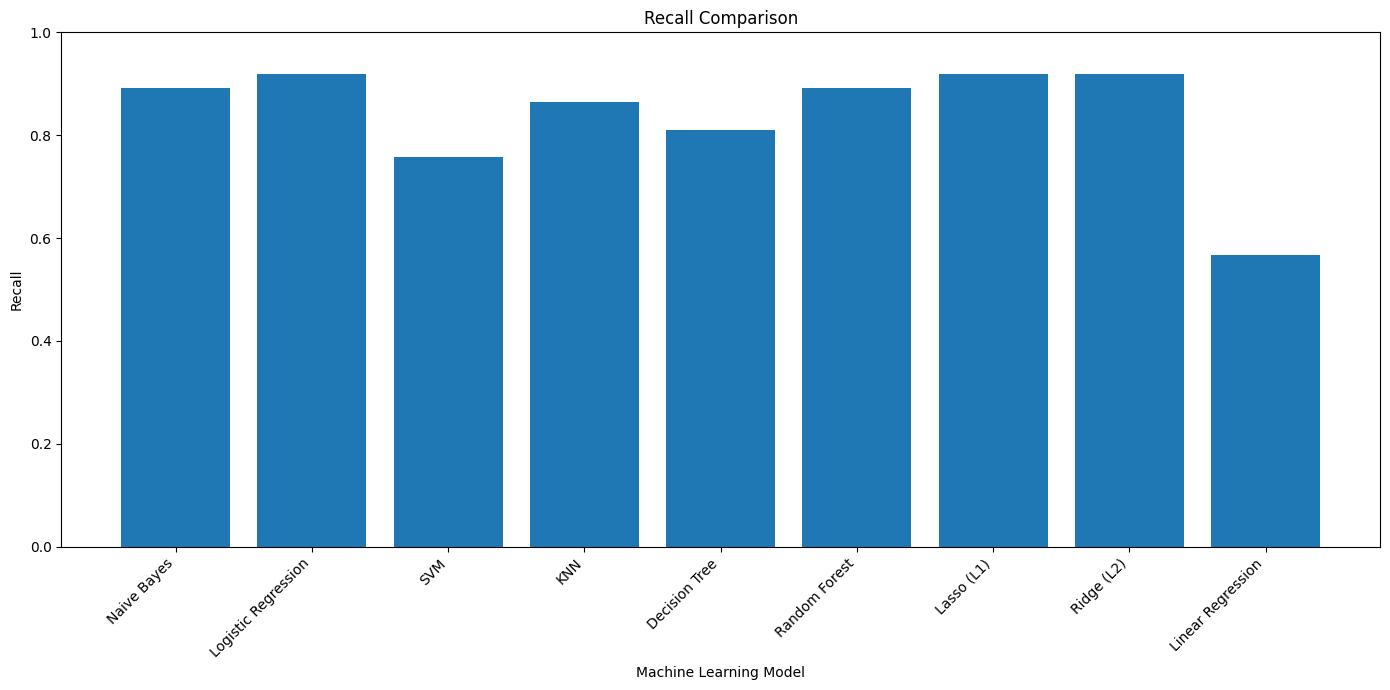

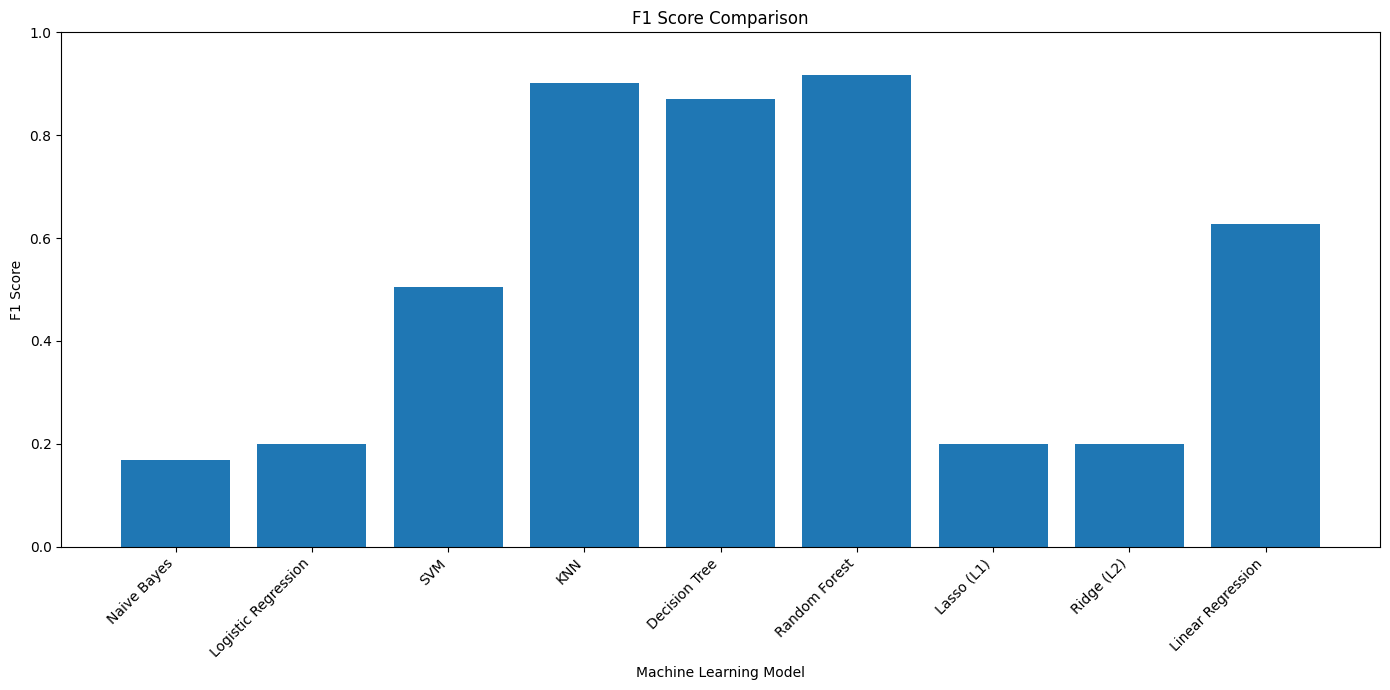

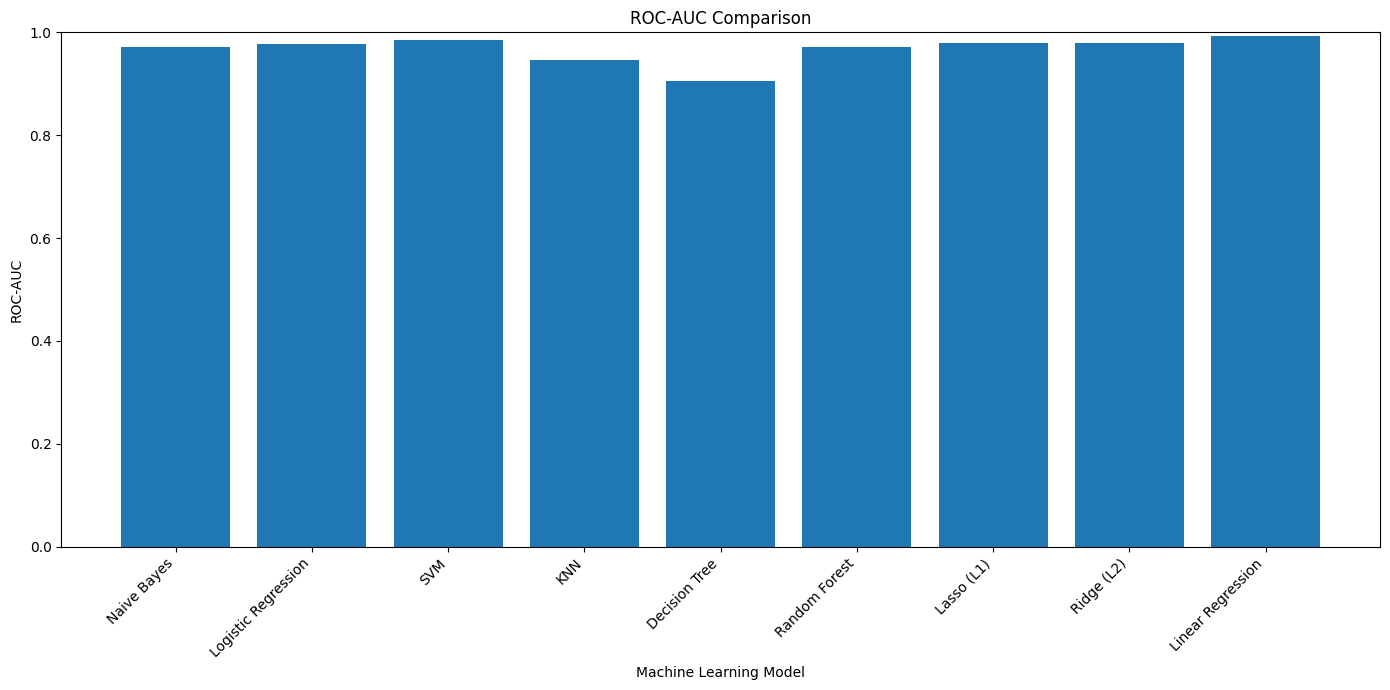

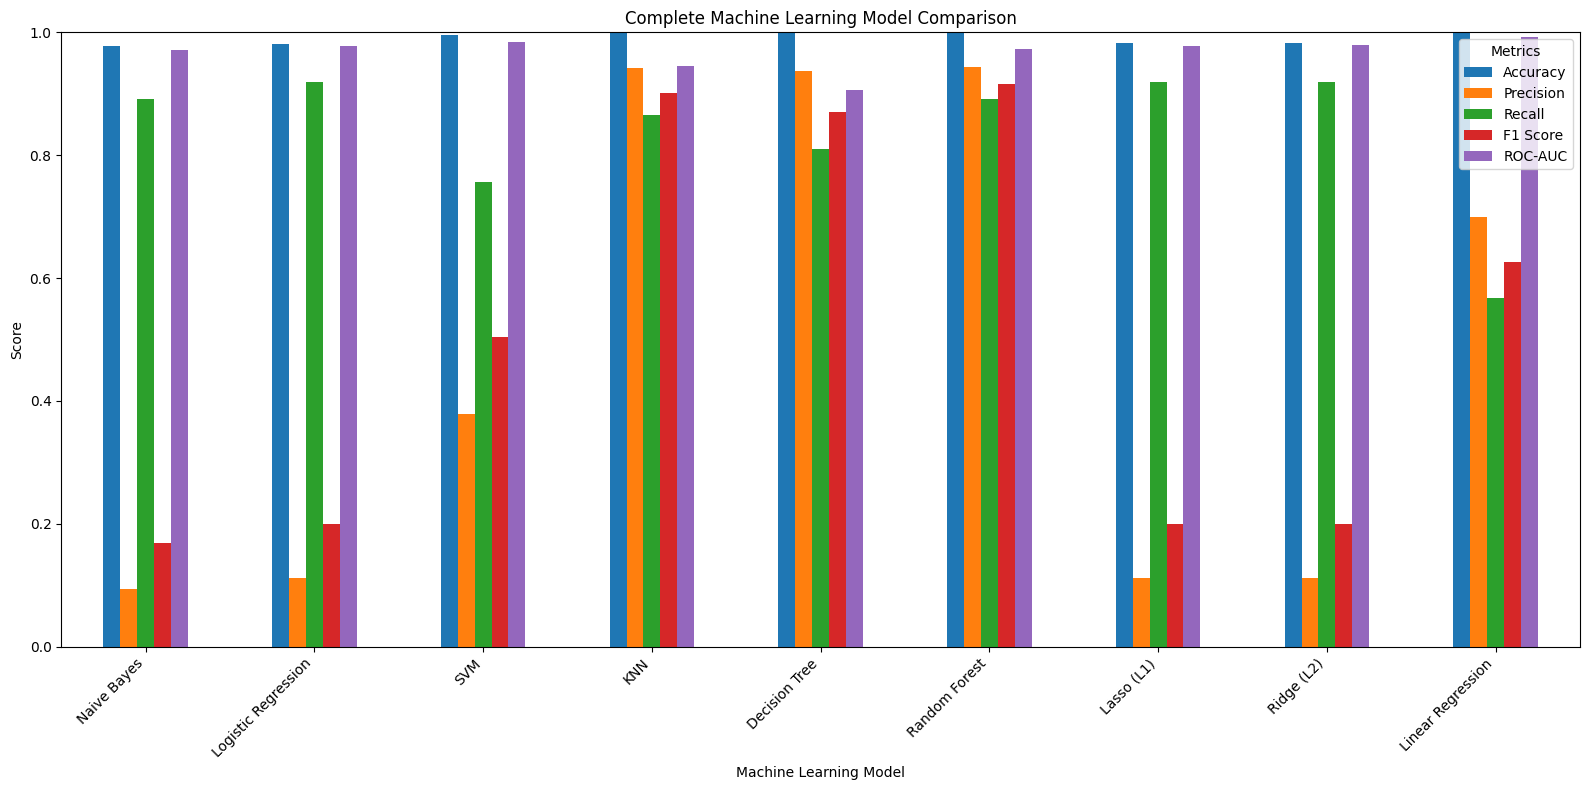



RESULTS SAVED
model_comparison_results.csv created successfully.


In [2]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# ML MODEL COMPARISON
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MACHINE LEARNING LIBRARIES
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Linear Regression
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("creditcard.csv")

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

print("\nBefore removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)


# ============================================================
# 4. CHECK CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

print(df["Class"].value_counts())

print("\nClass Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)


# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

# All columns except Class are input features
X = df.drop("Class", axis=1)

# Class is the target
y = df["Class"]

# Drop rows with NaN values in the target variable
# This is necessary because train_test_split with stratify cannot handle NaNs in y
nan_indices = y.isnull()
X = X[~nan_indices]
y = y[~nan_indices]


print("\n" + "=" * 70)
print("FEATURES AND TARGET")
print("=" * 70)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Class")


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 8. CREATE CLASSIFICATION MODELS
# ============================================================

models = {

    # 1. Naive Bayes
    "Naive Bayes":
        GaussianNB(),

    # 2. Logistic Regression
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),

    # 3. SVM
    "SVM":
        SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"
        ),

    # 4. KNN
    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    # 5. Decision Tree
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ),

    # 6. Random Forest
    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),

    # 7. Lasso-style Logistic Regression
    "Lasso (L1)":
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=1000,
            class_weight="balanced"
        ),

    # 8. Ridge-style Logistic Regression
    "Ridge (L2)":
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=1000,
            class_weight="balanced"
        )
}


# ============================================================
# 9. TRAIN CLASSIFICATION MODELS
# ============================================================

results = []

for name, model in models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    # Train model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test_scaled
    )

    # Probability
    y_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print("\nAccuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    print("\nConfusion Matrix:")

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(cm)

    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


# ============================================================
# 10. LINEAR REGRESSION
# ============================================================

print("\n")
print("=" * 70)
print("LINEAR REGRESSION")
print("=" * 70)

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

# Linear regression produces continuous values
linear_prediction = linear_model.predict(
    X_test_scaled
)

# Convert continuous values to 0 or 1
linear_class = (
    linear_prediction >= 0.5
).astype(int)


# Calculate metrics

linear_accuracy = accuracy_score(
    y_test,
    linear_class
)

linear_precision = precision_score(
    y_test,
    linear_class,
    zero_division=0
)

linear_recall = recall_score(
    y_test,
    linear_class,
    zero_division=0
)

linear_f1 = f1_score(
    y_test,
    linear_class,
    zero_division=0
)

linear_auc = roc_auc_score(
    y_test,
    linear_prediction
)


# Display

print("\nAccuracy :", round(linear_accuracy, 4))
print("Precision:", round(linear_precision, 4))
print("Recall   :", round(linear_recall, 4))
print("F1 Score :", round(linear_f1, 4))
print("ROC-AUC  :", round(linear_auc, 4))


# Add Linear Regression to results

results.append({
    "Model": "Linear Regression",
    "Accuracy": linear_accuracy,
    "Precision": linear_precision,
    "Recall": linear_recall,
    "F1 Score": linear_f1,
    "ROC-AUC": linear_auc
})


# ============================================================
# 11. CREATE FINAL RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)


# ============================================================
# 12. DISPLAY FINAL COMPARISON
# ============================================================

print("\n\n")
print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format,
            "ROC-AUC": "{:.4f}".format
        }
    )
)


# ============================================================
# 13. ACCURACY SORTING
# ============================================================

accuracy_result = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n\n")
print("=" * 70)
print("MODELS SORTED BY ACCURACY")
print("=" * 70)

print(
    accuracy_result[
        [
            "Model",
            "Accuracy"
        ]
    ].to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format
        }
    )
)


# ============================================================
# 14. F1 SCORE SORTING
# ============================================================

f1_result = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n\n")
print("=" * 70)
print("MODELS SORTED BY F1 SCORE")
print("=" * 70)

print(
    f1_result[
        [
            "Model",
            "F1 Score"
        ]
    ].to_string(
        index=False,
        formatters={
            "F1 Score": "{:.4f}".format
        }
    )
)


# ============================================================
# 15. ROC-AUC SORTING
# ============================================================

auc_result = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("\n\n")
print("=" * 70)
print("MODELS SORTED BY ROC-AUC")
print("=" * 70)

print(
    auc_result[
        [
            "Model",
            "ROC-AUC"
        ]
    ].to_string(
        index=False,
        formatters={
            "ROC-AUC": "{:.4f}".format
        }
    )
)


# ============================================================
# 16. BEST MODEL BASED ON F1 SCORE
# ============================================================

best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("\n\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Best Model based on F1 Score:",
    best_model["Model"]
)

print(
    "F1 Score:",
    round(best_model["F1 Score"], 4)
)

print(
    "Accuracy:",
    round(best_model["Accuracy"], 4)
)

print(
    "Precision:",
    round(best_model["Precision"], 4)
)

print(
    "Recall:",
    round(best_model["Recall"], 4)
)

print(
    "ROC-AUC:",
    round(best_model["ROC-AUC"], 4)
)


# ============================================================
# 17. ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title(
    "Accuracy Comparison of Machine Learning Models"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

# Display values above bars
for i, value in enumerate(
    results_df["Accuracy"]
):

    plt.text(
        i,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 18. PRECISION GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["Precision"]
)

plt.title(
    "Precision Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Precision"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 19. RECALL GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["Recall"]
)

plt.title(
    "Recall Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Recall"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. F1 SCORE GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title(
    "F1 Score Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "F1 Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. ROC-AUC GRAPH
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["ROC-AUC"]
)

plt.title(
    "ROC-AUC Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "ROC-AUC"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. COMPLETE METRICS COMPARISON
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df.set_index(
    "Model"
)[metrics].plot(
    kind="bar",
    figsize=(16, 8)
)

plt.title(
    "Complete Machine Learning Model Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. SAVE RESULTS TO CSV
# ============================================================

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\n")
print("=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(
    "model_comparison_results.csv created successfully."
)
